In [ ]:
import numpy as np
from qutip import *
from scipy.linalg import sqrtm, eigvalsh
from scipy.stats import linregress
from numba import njit, prange
import pickle
import os
import time

In [ ]:
%matplotlib ipympl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display, Math

## Fidelity
Generic definition : 
$$ \mathcal{F}\left( \rho, \sigma \right) = \left( Tr \left[ \sqrt{ \sqrt{\rho} \sigma \sqrt{\rho} }\right] \right)^{2} $$ 
Definition for $ \rho $ Pure State and $ \sigma $ Mixed State : 
$$ \mathcal{F}\left( \rho, \sigma \right) = \langle \psi_{\sigma} | \sigma | \psi_{\sigma} \rangle $$
Definition for Pure State : 
$$ \mathcal{F}\left( \rho, \sigma \right) = |\langle \psi_{\rho} | \psi_{\sigma} \rangle|^{2} $$
Definition for Qubits : 
$$ \mathcal{F}\left( \rho, \sigma \right) = Tr\left( \rho \, \sigma \right) + 2 \sqrt{Det\left ( \rho \right) \, Det\left ( \sigma \right)} $$
## Trace Distance
Generic definition : 
$$ \mathcal{T}\left( \rho, \sigma \right) = \frac{1}{2} Tr \left[ \sqrt{\left( \rho - \sigma \right)^{\dagger} \left( \rho - \sigma  \right)} \right] $$
### Relationship : Fuchs-van de Graaf inequality
$$ 1 - \sqrt{\mathcal{F}\left( \rho, \sigma \right)} \leq \mathcal{T}\left( \rho, \sigma \right) \leq \sqrt{1 - \mathcal{F}\left( \rho, \sigma \right)} $$

In [ ]:
def fidelity_generic(rho, sigma):
    """
    Calculate the quantum fidelity between two generic density matrices.
    Formula: F(rho, sigma) = ( Tr[ sqrt( sqrt(rho) * sigma * sqrt(rho) ) ] )^2
    
    This version avoids scipy.linalg.sqrtm to prevent RuntimeWarnings, 
    using stable eigenvalue decomposition instead.
    
    Parameters:
        rho (numpy.ndarray): First density matrix (NxN).
        sigma (numpy.ndarray): Second density matrix (NxN).
        
    Returns:
        float: The fidelity between rho and sigma (real number between 0 and 1).
    """
    # 1. Square root of rho using eigenvalue decomposition
    evals_rho, evecs_rho = np.linalg.eigh(rho)
    # Truncate any negative noise to 0.0 before taking the square root
    evals_rho = np.maximum(evals_rho, 0.0) 
    sqrt_rho = evecs_rho @ np.diag(np.sqrt(evals_rho)) @ evecs_rho.conj().T
    
    # 2. Inner matrix: sqrt(rho) * sigma * sqrt(rho)
    inner_matrix = sqrt_rho @ sigma @ sqrt_rho
    
    # Force exact Hermiticity to remove any small imaginary noise
    inner_matrix = 0.5 * (inner_matrix + inner_matrix.conj().T)
    
    # 3. Trace of the square root is the sum of the square roots of the eigenvalues
    evals_inner = eigvalsh(inner_matrix)
    # Again, truncate negative noise to 0.0 before square root
    evals_inner = np.maximum(evals_inner, 0.0)
    
    fidelity = np.sum(np.sqrt(evals_inner))**2
    
    # Ensure numerical errors do not push fidelity slightly above 1.0
    return min(1.0, fidelity)
    

In [ ]:
@njit
def fidelity_qubit(rho, sigma):
    """
    Calculate the exact quantum fidelity between two single-qubit (2x2) density matrices.
    Formula: F(rho, sigma) = Tr(rho * sigma) + 2 * sqrt(Det(rho) * Det(sigma))
    """
    # Trace of the matrix product
    tr_term = np.real(np.trace(rho @ sigma))
    
    # Determinants of the two density matrices
    det_rho = np.real(np.linalg.det(rho))
    det_sigma = np.real(np.linalg.det(sigma))
    
    # FIX NUMERICO: Tronchiamo a 0 gli eventuali valori negativi infinitesimi
    det_rho = max(0.0, det_rho)
    det_sigma = max(0.0, det_sigma)
    
    # Calculate fidelity using the analytical formula for qubits
    fidelity = tr_term + 2.0 * np.sqrt(det_rho * det_sigma)
    
    return fidelity

In [ ]:
def trace_distance_generic(rho, sigma):
    """
    Calculate the Trace Distance between two generic density matrices.
    Formula: T(rho, sigma) = 1/2 * Tr[ sqrt( (rho - sigma)^dagger * (rho - sigma) ) ]
    
    Parameters:
        rho (numpy.ndarray): First density matrix (NxN).
        sigma (numpy.ndarray): Second density matrix (NxN).
        
    Returns:
        float: The trace distance between rho and sigma (real number between 0 and 1).
    """
    # Difference between the matrices
    diff = rho - sigma
    
    # Force exact Hermiticity to remove numerical noise
    diff = 0.5 * (diff + diff.conj().T)
    
    # Calculate the eigenvalues of the strictly Hermitian matrix 'diff'
    eigenvalues = eigvalsh(diff)
    
    # Trace distance is half the sum of the absolute eigenvalues
    t_dist = 0.5 * np.sum(np.abs(eigenvalues))
    
    # Ensure it stays within physical bounds
    return min(1.0, t_dist)
    

In [ ]:
def trace_distance_qubit(rho, sigma):
    """
    Calculate the exact Trace Distance between two single-qubit (2x2) density matrices.
    For a 2x2 traceless Hermitian matrix (rho - sigma), Det(diff) = -lambda^2 <= 0.
    Therefore, the Trace Distance simplifies to sqrt(-Det(rho - sigma)).
    
    Parameters:
        rho (numpy.ndarray): First density matrix (2x2).
        sigma (numpy.ndarray): Second density matrix (2x2).
        
    Returns:
        float: The trace distance between rho and sigma.
    """
    # Difference between the matrices
    diff = rho - sigma
    
    # Determinant of the difference
    det_diff = np.real(np.linalg.det(diff))
    
    # Since det_diff should be <= 0, -det_diff should be >= 0.
    # We use max(0.0, ...) to truncate any negative noise before applying sqrt.
    val_under_sqrt = max(0.0, -det_diff)
    
    t_dist = np.sqrt(val_under_sqrt)
    
    return min(1.0, t_dist)
    

In [ ]:
@njit
def fidelity_qubit_single_term(p00, p11, c10, c01, sigma):
    """
    Build the density matrix from its elements and then
    Calculate the exact quantum fidelity between two single-qubit (2x2) density matrices.
    Formula: F(rho, sigma) = Tr(rho * sigma) + 2 * sqrt(Det(rho) * Det(sigma))
    """
    # 1. Density Matrix build up 
    rho = np.zeros((2, 2), dtype=np.complex128)
    rho[0,0] = p00
    rho[0,1] = c01
    rho[1,0] = c10
    rho[1,1] = p11

    # 2. Trace of the matrix product (Calculated explicitly for 2x2 to avoid Numba issues)
    prod = rho @ sigma
    tr_term = prod[0,0].real + prod[1,1].real
    
    # 3. Determinants of the two 2x2 density matrices (ad - bc)
    det_rho = (rho[0,0] * rho[1,1] - rho[0,1] * rho[1,0]).real
    det_sigma = (sigma[0,0] * sigma[1,1] - sigma[0,1] * sigma[1,0]).real
    
    # 4. Numerical FIX: Truncate to 0 any infinitesimal negative values
    det_rho = max(0.0, det_rho)
    det_sigma = max(0.0, det_sigma)
    
    # 5. Calculate fidelity using the analytical formula for qubits
    fidelity = tr_term + 2.0 * np.sqrt(det_rho * det_sigma)
    
    return fidelity

In [ ]:
@njit
def trace_distance_qubit_single_term(p00, p11, c10, c01, sigma):
    """
    Build the density matrix from its elements and then
    Calculate the exact Trace Distance between two single-qubit (2x2) density matrices.
    For a 2x2 traceless Hermitian matrix (rho - sigma), Det(diff) = -lambda^2 <= 0.
    Therefore, the Trace Distance simplifies to sqrt(-Det(rho - sigma)).
    
    Parameters:
        rho (numpy.ndarray): First density matrix (2x2).
        sigma (numpy.ndarray): Second density matrix (2x2).
        
    Returns:
        float: The trace distance between rho and sigma.
    """
    # Density Matrix build up 
    rho = np.zeros((2, 2), dtype=np.complex128)
    rho[0,0] = p00
    rho[0,1] = c01
    rho[1,0] = c10
    rho[1,1] = p11
    
    # Difference between the matrices
    diff = rho - sigma
    
    # Determinant of the difference
    det_diff = (diff[0,0]*diff[1,1] - diff[0,1]*diff[1,0]).real
    
    # Since det_diff should be <= 0, -det_diff should be >= 0.
    # We use max(0.0, ...) to truncate any negative noise before applying sqrt.
    val_under_sqrt = max(0.0, -det_diff)
    
    t_dist = np.sqrt(val_under_sqrt)
    
    return min(1.0, t_dist)

In [ ]:
@njit
def compute_metrics_over_time(pop_10, pop_01, coh_1001, coh_0110, rho_lindblad_array):
    """
    Computes fidelity and trace distance over all time steps using Numba in C-speed.
    """
    time_steps = len(pop_10)
    
    fidelity_arr = np.zeros(time_steps)
    trace_dist_arr = np.zeros(time_steps)
    
    for t in range(time_steps):
        fidelity_arr[t] = fidelity_qubit_single_term(
            pop_10[t], pop_01[t], coh_1001[t], coh_0110[t], rho_lindblad_array[t]
        )
        trace_dist_arr[t] = trace_distance_qubit_single_term(
            pop_10[t], pop_01[t], coh_1001[t], coh_0110[t], rho_lindblad_array[t]
        )
        
    return fidelity_arr, trace_dist_arr

In [ ]:
# =====================================================================
# NUMBA OPTIMIZED LOOP FOR ALL INDIVIDUAL TRAJECTORIES (2D ARRAYS)
# =====================================================================
@njit(parallel=True)
def compute_metrics_all_trajectories(pop_10, coh_1001, coh_0110, pop_01, rho_lindblad_array):
    """
    Computes fidelity and trace distance for ALL individual trajectories.
    Inputs are 2D arrays: (time_steps, N_traj) and Lindblad 3D array.
    Uses parallel processing (prange) for maximum speed.
    """
    time_steps = pop_10.shape[0]
    N_traj = pop_10.shape[1]
    
    # Pre-allocate output 2D arrays (time_steps, N_traj)
    fidelity_matrix = np.zeros((time_steps, N_traj))
    trace_dist_matrix = np.zeros((time_steps, N_traj))
    
    # Outer loop over time
    for t in range(time_steps):
        # Parallel loop over all trajectories (this uses all your CPU cores!)
        for n in prange(N_traj):
            fidelity_matrix[t, n] = fidelity_qubit_single_term(
                pop_10[t, n], pop_01[t, n], coh_1001[t, n], coh_0110[t, n], rho_lindblad_array[t]
            )
            trace_dist_matrix[t, n] = trace_distance_qubit_single_term(
                pop_10[t, n], pop_01[t, n], coh_1001[t, n], coh_0110[t, n], rho_lindblad_array[t]
            )
            
    return fidelity_matrix, trace_dist_matrix

## General Setup

In [ ]:
# ====================================
# Physical & Simulation Parameters
# ====================================
# Theta angle in degrees, H_Coll Direction
theta_target_deg = 60.0  # change angle here
theta_rad = np.radians(theta_target_deg)

# Site selector: 0 for |10>, 1 for |01>
site_index = 0

# Time step
dt = 0.01

# Number of trajectories to analyze
N_traj = 10000          

In [ ]:
# ===========================
# General Setup for Plotting
# ===========================
# --- 1. Output Directory---

if theta_target_deg.is_integer():
    angle_folder = str(int(theta_target_deg))
else:
    angle_folder = str(theta_target_deg)

Output_dir = os.path.join("../Results/Plot/Fidelity/Complete", angle_folder)
os.makedirs(Output_dir, exist_ok=True)

# --- 2. Global Style Settings (Matplotlib rcParams) ---
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'figure.autolayout': True # plt.tight_layout()
})

# --- 3. Automatic Figure Saving Function ---
def save_fig(fig, filename):
    """
    Saves the figure in both PNG or PDF
    """
    path_png = os.path.join(Output_dir, f"{filename}.png")
    # path_pdf = os.path.join(Output_dir, f"{filename}.pdf")  # save in pdf
    
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    # fig.savefig(path_pdf, bbox_inches='tight') # save in pdf
    print(f"Figure saved in: {Output_dir}/{filename}")

In [ ]:
# =================
# Input Data Setup
# =================
Input_dir = "../Results/Data/Complete_rho/normal"  # <-- change here if needed

# Format theta and dt for filename 
theta_str = f"{theta_rad:.6f}".replace(".", "p")
dt_str = f"{dt:.6f}".replace(".", "p")

# File name
filename = f"result_theta{theta_str}_dt{dt_str}_Ntraj20000.npz"
filepath = os.path.join(Input_dir, filename)

print(f"Analisi impostata per theta = {theta_target_deg}°")
print(f"File target: {filename}")

 ### Data Extraction

In [ ]:
if not os.path.exists(filepath):
    print(f"ERRORE: The file {filepath} doesn't exist. Check file name.")
else:
    # Load .npz input containing data
    data = np.load(filepath)
    
    times = data['times']
    n_times = len(times)
    
    print("Matrix extraction in progress")
    
    # =======================
    # 1. Lindblad Extraction
    # =======================
    rho_lindblad_complete = data['rho_list_lindblad']  # 4x4 dimesion
    
    # Populations : Index (2,2) -> |10><10|, Index (1,1)  -> |01><01|    
    pop_lindblad_10 = np.real(rho_lindblad_complete[:, 2, 2])
    pop_lindblad_01 = np.real(rho_lindblad_complete[:, 1, 1])
    
    # Coherences: Index (2,1) -> |10><01|, Index (1, 2) -> |01><10|  ATTENTION : inverted respect to Trajectories, already inverted here
    cohe_lindblad_10_01 = rho_lindblad_complete[:, 1, 2] 
    cohe_lindblad_01_10 = rho_lindblad_complete[:, 2, 1]

    rho_lindblad = np.zeros((n_times, 2, 2), dtype=np.complex128)

    for t in range(n_times):
    
        # Populations : Index (2,2) -> |10><10|, Index (1,1)  -> |01><01| INVERTED respect to Trajectories, already inverted here
        rho_lindblad[t, 0, 0] = rho_lindblad_complete[t, 2, 2]  # |10><10|
        rho_lindblad[t, 1, 1] = rho_lindblad_complete[t, 1, 1]  # |01><01|
        
        # Coherences ATTENTION : inverted respect to Trajectories, already inverted here
        rho_lindblad[t, 0, 1] = rho_lindblad_complete[t, 2, 1]  # |10><01|
        rho_lindblad[t, 1, 0] = rho_lindblad_complete[t, 1, 2]  # |01><10|
        
    # ================================
    # 2.  Raw Trajectories Extraction
    # ================================
    
    pop_traj_10 = data['pop_00']
    pop_traj_01 = data['pop_11']
    
    cohe_traj_10_01 = data['coh_10_01'] 
    cohe_traj_01_10 = data['coh_01_10']

    print("Data extraction completed")

## Purity

$ P = Tr[\rho^2]  $

In [ ]:
# =============================================================
# Purity Check via simplified formula: p10^2 + p01^2 + 2*|c|^2 
# =============================================================

print("Starting Purity Check")
start_time = time.time()

n_times, N_traj_tot = pop_traj_10.shape
max_deviation = 0.0

# Chunking to reduce RAM usage
CHUNK_SIZE = 5000
n_chunks = int(np.ceil(N_traj_tot / CHUNK_SIZE))

for i in range(n_chunks):
    start_idx = i * CHUNK_SIZE
    end_idx = min((i + 1) * CHUNK_SIZE, N_traj_tot)
    
    p10_chunk = pop_traj_10[:, start_idx:end_idx]
    p01_chunk = pop_traj_01[:, start_idx:end_idx]
    c_chunk = cohe_traj_10_01[:, start_idx:end_idx]
    
    # Purity p10^2 + p01^2 + 2*|c|^2
    purity_chunk = p10_chunk**2 + p01_chunk**2 + 2 * (np.abs(c_chunk)**2)
    
    # Max deviation from theroretical value 1.0
    chunk_max_dev = np.max(np.abs(1.0 - purity_chunk))
    
    if chunk_max_dev > max_deviation:
        max_deviation = chunk_max_dev

print(f"Check completed in {time.time() - start_time:.4f} seconds.")
print(f"Maximum deviation from ideal purity (1.0): {max_deviation:.4e}")

# Automatic evaluation of the result
if max_deviation < 1e-10:
    print("\n✅ Test Passed: all trajectoreis are always perfectly pure")
else:
    print("\n⚠️ Warning: Found a significant deviation from purity. Check the normalization in the simulator.")

## Fidelity calculation

In [ ]:
# ==========================================================================
# COMPLETE FIDELITY & TRACE DISTANCE CALCULATION (ALL TRAJECTORIES)
# ==========================================================================

print("Starting complete calculation for all trajectories...")

# Call the parallel Numba function for 2D arrays
all_fidelity_list, all_trace_dist_list = compute_metrics_all_trajectories(
    pop_traj_10, cohe_traj_10_01, cohe_traj_01_10, pop_traj_01, rho_lindblad
)

print(f"Calculation finished for all trajectories. Shape of fidelity array: {all_fidelity_list.shape}")


In [ ]:
# ========================================================
# SIMPLIFIED FIDELITY CALCULATION - (ON THE FLY)
# Fidelity for Pure and mixed states: F = Tr(rho * sigma) 
# ========================================================

print("Starting fidelity calculation")
start_time = time.time()

n_times, N_traj_tot = pop_traj_10.shape
N_traj_plot = N_traj_tot

# Prepariamo la heatmap direttamente in float32 (dimezza la RAM vs float64)
fid_bins = 150
fid_edges = np.linspace(0.0, 1.0, fid_bins + 1)
heatmap_simplified = np.zeros((fid_bins, n_times), dtype=np.float32)

for t in range(n_times):
    P00_t  = pop_traj_10[t, :N_traj_plot]
    P11_t  = pop_traj_01[t, :N_traj_plot]
    C10_t  = cohe_traj_10_01[t, :N_traj_plot]
    C01_t  = cohe_traj_01_10[t, :N_traj_plot]

    P00_L  = pop_lindblad_10[t]
    P11_L  = pop_lindblad_01[t]
    C10_L  = cohe_lindblad_10_01[t]  
    C01_L  = cohe_lindblad_01_10[t]   

    # Tr(rho_traj * rho_L) = P00_traj * P00_L + C01_traj * C10_L + C10_traj * C01_L + P11_traj * P11_L
    fid_t = np.real(
            P00_t * P00_L +   # P00_traj * P00_L 
            C01_t * C10_L +   # C01_traj * C10_Lind
            C10_t * C01_L +   # C10_traj * C01_Lind
            P11_t * P11_L)    # P11_traj * P11_L

    counts, _ = np.histogram(fid_t, bins=fid_edges)
    heatmap_simplified[:, t] = counts

print(f"Calculation completed in {time.time() - start_time:.4f} seconds")


## Plot 

In [ ]:
# ==========================================
# Fidelity for Avg Traj vs Lindblad in time
# ==========================================

plt.close('all')

# List of trajectories to average over
N_list = [100, 1000, 10000]  

# Create the figure and axis. Note: figsize is handled by global rcParams
fig01, ax = plt.subplots()

for N in N_list:
    # Average of the 4 density matrix components over N trajectories
    pop_10_m   = np.mean(pop_traj_10[:, :N], axis=1)
    pop_01_m   = np.mean(pop_traj_01[:, :N], axis=1)
    coh_1001_m = np.mean(cohe_traj_10_01[:, :N], axis=1)
    coh_0110_m = np.mean(cohe_traj_01_10[:, :N], axis=1)

    # Rebuild the average density matrix for each time step
    rho_list_avg = np.zeros((n_times, 2, 2), dtype=np.complex128)
    for t in range(n_times): 
        rho_list_avg[t] = [[pop_10_m[t], coh_1001_m[t]], [coh_0110_m[t], pop_01_m[t]]]

    # Rebuild the Lindblad density matrix for each time step
    rho_list_lindblad = np.zeros((n_times, 2, 2), dtype=np.complex128)
    for t in range(n_times): 
        rho_list_lindblad[t] = [[pop_lindblad_10[t], cohe_lindblad_10_01[t]], [cohe_lindblad_01_10[t], pop_lindblad_01[t]]]

    # Fidelity calculation for each time step
    fidelity_list = np.zeros((n_times), dtype=np.float32)
    for t in range(n_times): 
        fidelity_list[t] = fidelity_qubit(rho_list_avg[t], rho_list_lindblad[t])

    # Plot the current N curve
    alpha_val = 1.0
    lw = 1.5 
    ax.plot(times, fidelity_list, label=f'N_traj = {N}', alpha=alpha_val, linewidth=lw)

# Apply labels and title (fonts are set globally)
ax.set_xlabel("Time steps")
ax.set_ylabel(r"Fidelity $\mathcal{F}(\rho_{mean}, \rho_L)$")
ax.set_title(f"Evolution of Avg Fidelity vs Lindblad | $\\theta$ = {theta_target_deg}°")
ax.legend()

# Automatically save the figure using the global parameters defined at the top
filename_avg = f"Avg_Fidelity_Evolution_Theta_{theta_str}_dt_{dt_str}"
#save_fig(fig01, filename_avg)

plt.show()

In [ ]:
# ===============================
# PLOT HEATMAP FIDELITY COMPLETE
# ===============================

plt.close('all')

# Transpose the list to get shape (n_trajectories, n_timesteps)
# Note: assigned to a new variable to prevent double-transposition if cell is run twice
fidelity_array = np.array(all_fidelity_list).T

n_traj, n_times = fidelity_array.shape
times_array = np.arange(n_times) 

# Heatmap bin parameters
n_bins = 150 
fidelity_bins = np.linspace(0, 1, n_bins + 1)
heatmap_complete = np.zeros((n_bins, n_times))

# Compute the histogram for each time step
for t in range(n_times):
    counts, _ = np.histogram(fidelity_array[:, t], bins=fidelity_bins)
    heatmap_complete[:, t] = counts

# Create the figure. Here we explicitly set a wider figsize for the heatmap_complete
fig, ax = plt.subplots(figsize=(12, 5))

# Mask zero counts to improve visualization
heatmap_masked_complete = np.ma.masked_where(heatmap_complete == 0, heatmap_complete) 

im = ax.imshow(
    heatmap_masked_complete,
    aspect='auto',
    origin='lower',
    extent=[times_array[0], times_array[-1], 0, 1],
    cmap='viridis',
    interpolation='nearest',
    vmin=1, vmax=np.max(heatmap_complete)*0.8
)

# Add colorbar without manual fontsize
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Number of trajectories')

# Apply labels and dynamic title
ax.set_xlabel('Time')
ax.set_ylabel('Fidelity')
ax.set_title(f'Fidelity Distribution over Time | $\\theta$ = {theta_target_deg}°')

# Automatically save the heatmap figure
filename_heatmap = f"Heatmap_Fidelity_Complete_Theta_{theta_str}_dt_{dt_str}"
#save_fig(fig, filename_heatmap)

plt.show()

In [ ]:
# =================================
# PLOT HEATMAP FIDELITY SIMPLIFIED 
# =================================

plt.close('all')

# Create the figure. We override the default figsize to make it wider for the heatmap
fig, ax = plt.subplots(figsize=(12, 7))

# Mask the 0 values so they don't mess up the logarithmic scale
heatmap_masked_simplified = np.ma.masked_where(heatmap_simplified == 0, heatmap_simplified)

# Plot the heatmap using LogNorm
image = ax.imshow(
    heatmap_masked_simplified,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], 0.0, 1.0],
    cmap='magma', # 'magma' or 'viridis' work best
    interpolation='nearest',
    vmin=1, vmax=np.max(heatmap_simplified)*0.5
)

# Add colorbar with its label
cbar = fig.colorbar(image, ax=ax, pad=0.02)
cbar.set_label('Fraction of trajectories (Log Scale)')

# Apply labels and dynamic title using global parameters
ax.set_title(f"Fidelity Probability Density $\mathcal{{F}}(\\rho_{{traj}}, \\rho_{{L}})$ | $\\theta$ = {theta_target_deg}°")
ax.set_xlabel("Time steps")
ax.set_ylabel("Fidelity")

# Automatically save the figure (PNG + PDF)
#filename_heatmap_simplified = f"Heatmap_Fidelity_Simplified_Theta_{theta_target_deg}deg"
#save_fig(fig, filename_heatmap_simplified)

plt.show()

In [ ]:
# =============================================
# Fidelity for a Single Trajectory vs Lindblad
# =============================================

plt.close('all')

# Choose which trajectory index to plot 
sample_idx = 0

# Extract the fidelity values for the chosen trajectory across all time steps
# We use the all_fidelity_list computed previously with Numba
single_traj_fidelity = all_fidelity_list[:, sample_idx]

# Create figure and axis using global aesthetic settings
fig, ax = plt.subplots()

# Plot the single trajectory
ax.plot(
    times, 
    single_traj_fidelity, 
    label=f'Single Traj (idx = {sample_idx})', 
    color='dodgerblue', 
    linewidth=1.5, 
    alpha=0.9
)

# Set labels and title
ax.set_xlabel("Time steps")
ax.set_ylabel(r"Fidelity $\mathcal{F}(\rho_{traj}^{(i)}, \rho_L)$")
ax.set_title(f"Single Trajectory Fidelity vs Lindblad | $\\theta$ = {theta_target_deg}°")
ax.legend()

# Automatically save the figure dynamically
# filename_single = f"Single_Traj_Fidelity_idx{sample_idx}_Theta_{theta_target_deg}deg"
# save_fig(fig, filename_single)

plt.show()

In [ ]:
# =================================================================
# Single Trajectory and Avg Fidelity over Trajectories vs Lindblad
# =================================================================

plt.close('all')

# Average fifelity across all trajectories for each time step
avg_fidelity_over_traj = np.mean(all_fidelity_list, axis=1)

# Choose which trajectory index to plot 
sample_idx = 0

# Extract the fidelity values for the chosen trajectory across all time steps
# We use the all_fidelity_list computed previously with Numba
single_traj_fidelity = all_fidelity_list[:, sample_idx]

# Create figure and axis using global aesthetic settings
fig, ax = plt.subplots()

# Plot the single trajectory
ax.plot(
    times, 
    avg_fidelity_over_traj, 
    label=f'Avg Fidelity Over Trajectories', 
    color='blue', 
    linewidth=1.5, 
    alpha=0.9
)

# Plot the single trajectory
ax.plot(
    times, 
    single_traj_fidelity, 
    label=f'Single Traj (idx = {sample_idx})', 
    color='red', 
    linewidth=1.5, 
    alpha=0.9
)

# Set labels and title
ax.set_xlabel("Time steps")
ax.set_ylabel(r"Single Traj and Avg Fidelity Over Trajectories")
ax.set_title(f"Single Traj and Avg Fidelity Over Trajectories vs Lindblad | $\\theta$ = {theta_target_deg}°")
ax.legend()

# Automatically save the figure dynamically
# filename_single = f"Single Traj and Avg Fidelity Over Trajectories vs Lindblad | $\\theta$ = {theta_target_deg}°"
# save_fig(fig, filename_single)

plt.show()

## Trace Distance calculation

In [ ]:
# ============================================
# PLOT HEATMAP: COMPLETE TRACE DISTANCE
# ============================================
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

plt.close('all')

# Transpose the array to get shape (n_trajectories, n_timesteps)
td_array = np.array(all_trace_dist_list).T

n_traj, n_times = td_array.shape

# Heatmap bin parameters for Trace Distance (values range from 0 to 1)
n_bins = 150 
td_bins = np.linspace(0.0, 1.0, n_bins + 1)
heatmap_td = np.zeros((n_bins, n_times))

# Compute the histogram for each time step
for t in range(n_times):
    counts, _ = np.histogram(td_array[:, t], bins=td_bins)
    # Normalize by the total number of trajectories to get a probability fraction
    heatmap_td[:, t] = counts / n_traj

# Create the figure with a wider format for better time resolution
fig, ax = plt.subplots(figsize=(12, 6))

# Mask exactly zero values so they appear as background and don't break the LogNorm
heatmap_masked_td = np.ma.masked_where(heatmap_td == 0, heatmap_td) 

# The minimum non-zero fraction possible is 1 / n_traj
vmin_val = 1.0 / n_traj  

# Plot the heatmap using Logarithmic Normalization
im = ax.imshow(
    heatmap_masked_td,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], 0.0, 1.0],
    cmap='magma', 
    norm=LogNorm(vmin=vmin_val, vmax=1.0),
    interpolation='nearest'
)

# Add colorbar with explicit label
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Fraction of trajectories (Log Scale)')

# Apply labels and dynamic title
ax.set_xlabel('Time')
ax.set_ylabel(r'Trace Distance $\mathcal{T}(\rho_{traj}, \rho_L)$')
ax.set_title(f'Trace Distance Probability Density over Time | $\\theta$ = {theta_target_deg}°')

# Automatically save the heatmap figure (uncomment when needed)
# filename_heatmap_td = f"Heatmap_Trace_Distance_Complete_Theta_{theta_str}_dt_{dt_str}"
# save_fig(fig, filename_heatmap_td)

plt.show()

In [ ]:
# ==========================================================
# Calcolo della Trace Distance della Media per N traiettorie
# ==========================================================

N_list = [100, 1000, 10000]

plt.figure()

for N in N_list:
    # 1. Calcolo rapido delle popolazioni e coerenze medie per N traiettorie
    pop_10_m = np.mean(pop_traj_10[:, :N], axis=1)
    pop_01_m = np.mean(pop_traj_01[:, :N], axis=1)
    cohe_10_01_m = np.mean(cohe_traj_10_01[:, :N], axis=1)
    cohe_01_10_m = np.mean(cohe_traj_01_10[:, :N], axis=1)
    
    # 2. Differenza vettorizzata con Lindblad
    D_10_m = pop_10_m - pop_lindblad_10
    D_01_m = pop_01_m - pop_lindblad_01
    D_10_01_m = cohe_10_01_m - cohe_lindblad_10_01
    D_01_10_m = cohe_01_10_m - cohe_lindblad_01_10
    
    # 3. Determinante della differenza
    det_diff_m = np.real(D_10_m * D_01_m - D_10_01_m * D_01_10_m)
    
    # 4. Trace Distance = sqrt(-Det)
    val_under_sqrt_m = np.maximum(0.0, -det_diff_m)
    td_mean_array = np.sqrt(val_under_sqrt_m)
    
    # Stile dinamico: la curva a 10000 sarà la più marcata
    alpha_val = 0.6 if N < 10000 else 1.0
    lw = 1.5 if N < 10000 else 2.5
    
    plt.plot(times, td_mean_array, label=f'N_traj = {N}', alpha=alpha_val, linewidth=lw)
    
plt.xlabel("Time steps")
plt.ylabel("Trace Distance $T(\\rho_{mean}, \\rho_L)$")
plt.title(f"Evolution in time of Avg Trace Distance vs Lindblad | $\\theta$ = {theta_target_deg}°")
plt.legend()

#plt.ylim(-0.005, 0.1)

plt.show()

## Variance Analysis

### Fidelity

In [ ]:
# =====================
# Variance Calculation
# =====================
variance_fidelity= np.var(all_fidelity_list, axis=1)

plt.close('all')

fig, ax = plt.subplots()
ax.plot(times, variance_fidelity, label='Variance of 1 - Fidelity', color='blue')   
ax.set_xlabel("Time steps")
ax.set_ylabel("Variance of 1 -Fidelity")
ax.set_title(f"Variance of 1 -Fidelity across Trajectories | $\\theta$ = {theta_target_deg}°")
ax.legend() 

# Automatically save figure 
filename= f"Fidelity_Variance_over_Trajectories_Theta_{theta_str}_dt_{dt_str}"
save_fig(fig, filename)

plt.show()

### Trace Distance

In [ ]:
# =====================
# Variance Calculation
# =====================
variance_trace_distance= np.var(all_trace_dist_list, axis=1)

plt.close('all')

fig, ax = plt.subplots()
ax.plot(times, variance_trace_distance, label='Variance of Trace Distance', color='red')   
ax.set_xlabel("Time steps")
ax.set_ylabel("Variance of Trace Distance")
ax.set_title(f"Variance of Trace Distance across Trajectories | $\\theta$ = {theta_target_deg}°")
ax.legend() 

# Automatically save figure 
filename= f"Trace_Distance_Variance_over_Trajectories_Theta_{theta_str}_dt_{dt_str}"
save_fig(fig, filename)

plt.show()

In [ ]:
# =========================
# SAVE STATISTICAL METRICS 
# =========================

# 1. Define the subdirectory name
subdir = "metrics"

# 2. Create the full path to the 'metrics' directory using the previously defined Input_dir
metrics_dir = os.path.join(Input_dir, subdir)

# 3. Check if the directory exists, if not, create it
if not os.path.exists(metrics_dir):
    os.makedirs(metrics_dir)
    print(f"Created directory: {metrics_dir}")

# 4. Define the final output filepath
output_filename = f"Metrics_Variance_Theta_{theta_target_deg}deg.npz"
output_filepath = os.path.join(metrics_dir, output_filename)

# Save everything into a compressed .npz file
np.savez_compressed(
    output_filepath,
    times=times,               
    var_td=variance_trace_distance,
    var_fid=variance_fidelity
)

print(f"Data successfully saved in: {output_filepath}")

### Multiple Angle Analysis

Saved Trace Distance comparison plot in: ../Results/Plot/Variance_Comparison/close_90_deg/Comparison_Trace_Distance_Variance.png


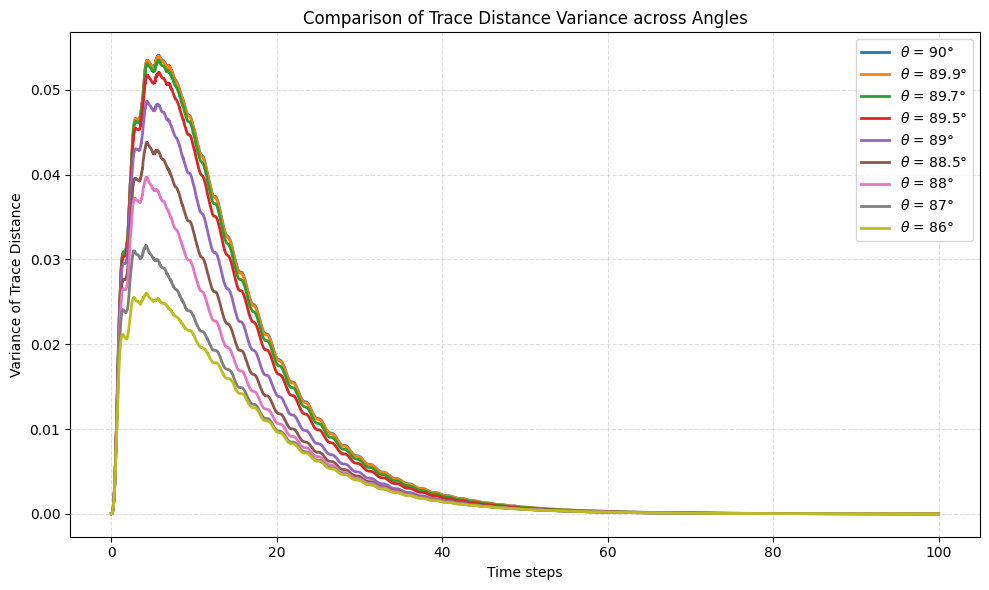

Saved Fidelity comparison plot in: ../Results/Plot/Variance_Comparison/close_90_deg/Comparison_Fidelity_Variance.png


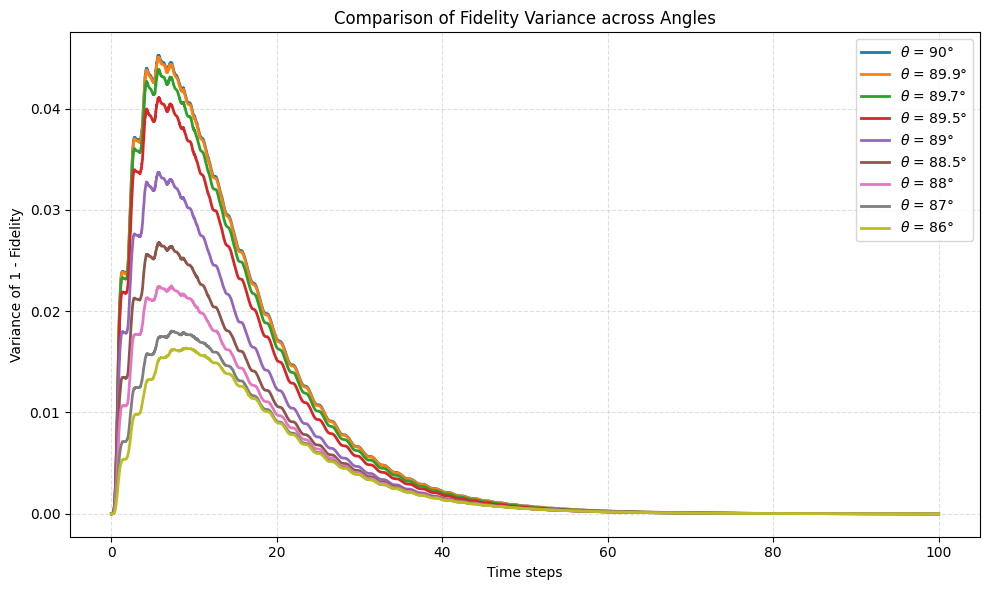

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================================
# LOAD, PLOT AND SAVE VARIANCES FOR MULTIPLE ANGLES
# ==========================================================

# 1. Define input and output directories
#Input_dir = "../Results/Data/Complete_rho/normal"
Input_dir = "../Results/Data/Complete_rho/close_90_deg"
metrics_dir = os.path.join(Input_dir, "metrics")

# Create a dedicated directory for comparative plots
#Output_dir = "../Results/Plot/Variance_Comparison/normal"
Output_dir = "../Results/Plot/Variance_Comparison/close_90_deg"

os.makedirs(Output_dir, exist_ok=True)

# 2. Define the list of successfully computed angles
# theta_list = [0, 30, 45, 60, 90]
theta_list = [0, 90, 89.9, 89.7, 89.5, 89, 88.5, 88, 87, 86]  

# ----------------------------------------------------------
# PLOT 1: TRACE DISTANCE VARIANCE
# ----------------------------------------------------------
fig_td, ax_td = plt.subplots(figsize=(10, 6))

for theta in theta_list:
    # Ensure correct filename format (float matching the save script)
    filename = f"Metrics_Variance_Theta_{float(theta)}deg.npz"
    filepath = os.path.join(metrics_dir, filename)
    
    # Check if the file exists to prevent crashes
    if os.path.exists(filepath):
        data = np.load(filepath)
        times = data['times']
        var_td = data['var_td']
        
        # Plot the data
        ax_td.plot(times, var_td, label=f'$\\theta$ = {theta}°', linewidth=2)
        data.close()
    else:
        print(f"Warning: File {filename} not found.")

ax_td.set_xlabel("Time steps")
ax_td.set_ylabel("Variance of Trace Distance")
ax_td.set_title("Comparison of Trace Distance Variance across Angles")
ax_td.legend()
ax_td.grid(alpha=0.4, linestyle='--')
fig_td.tight_layout()

# Save Plot 1
save_path_td = os.path.join(Output_dir, "Comparison_Trace_Distance_Variance.png")
fig_td.savefig(save_path_td, dpi=300, bbox_inches='tight')
print(f"Saved Trace Distance comparison plot in: {save_path_td}")

plt.show()

# ----------------------------------------------------------
# PLOT 2: FIDELITY VARIANCE
# ----------------------------------------------------------
fig_fid, ax_fid = plt.subplots(figsize=(10, 6))

for theta in theta_list:
    filename = f"Metrics_Variance_Theta_{float(theta)}deg.npz"
    filepath = os.path.join(metrics_dir, filename)
    
    if os.path.exists(filepath):
        data = np.load(filepath)
        times = data['times']
        var_fid = data['var_fid']
        
        ax_fid.plot(times, var_fid, label=f'$\\theta$ = {theta}°', linewidth=2)
        data.close()

ax_fid.set_xlabel("Time steps")
ax_fid.set_ylabel("Variance of 1 - Fidelity")
ax_fid.set_title("Comparison of Fidelity Variance across Angles")
ax_fid.legend()
ax_fid.grid(alpha=0.4, linestyle='--')
fig_fid.tight_layout()

# Save Plot 2
save_path_fid = os.path.join(Output_dir, "Comparison_Fidelity_Variance.png")
fig_fid.savefig(save_path_fid, dpi=300, bbox_inches='tight')
print(f"Saved Fidelity comparison plot in: {save_path_fid}")

plt.show()